# **Task: Email spam classification**

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

# Download the dataset first

In [99]:
!wget https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv -O sms.tsv

--2025-10-02 09:14:43--  https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 477907 (467K) [text/plain]
Saving to: ‘sms.tsv’

sms.tsv             100%[===================>] 466.71K  --.-KB/s    in 0.04s   

2025-10-02 09:14:43 (12.2 MB/s) - ‘sms.tsv’ saved [477907/477907]



# Load dataset

In [100]:
df = pd.read_csv('sms.tsv', sep='\t', header=None, names=["label", "text"])

In [101]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Map labels to numeric (ham=0, spam=1)

In [102]:
df["label_num"] = df["label"].map({"ham":0, "spam":1})

# Show first few rows

In [103]:
print(df.head())

  label                                               text  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0


# Shape of the dataset

In [104]:
print("Dataset Shape: ", df.shape)

Dataset Shape:  (5572, 3)


# Check first few rows

In [105]:
print("\nFirst 5 rows: ")
print(df.head())


First 5 rows: 
  label                                               text  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0


# Distribution of ham vs spam

In [106]:
print("\nClass Classification: ")
print(df["label"].value_counts())


Class Classification: 
label
ham     4825
spam     747
Name: count, dtype: int64


# Plot class distribution

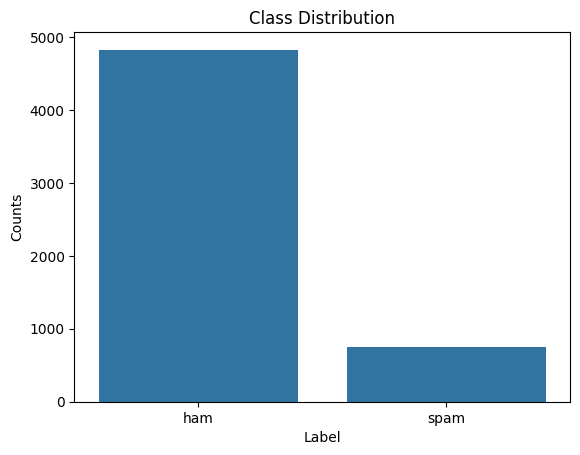

In [107]:
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Counts")
plt.show()

# Add message length column

In [108]:
df["length"] = df["text"].apply(len)

# Average length per class

In [109]:
print("\nAverage message length by class: ")
print(df.groupby("label")["length"].mean())


Average message length by class: 
label
ham      71.482487
spam    138.670683
Name: length, dtype: float64


# Plot message length distribution

array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

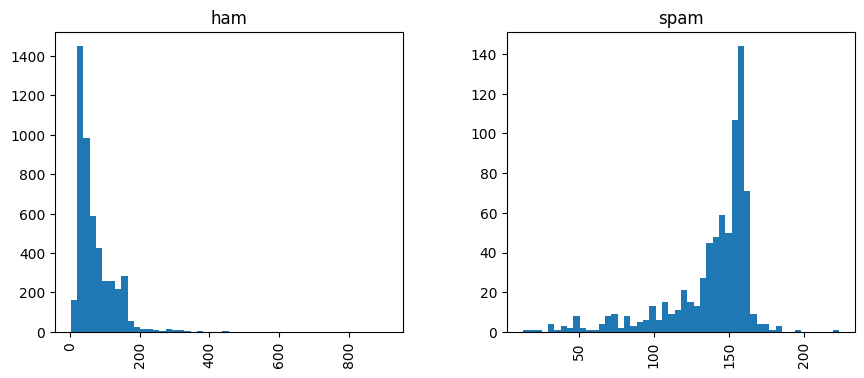

In [110]:
df.hist(column="length", by="label", bins=50, figsize=(10,4))

# Show sample messages

In [111]:
print("\nSample ham message:\n", df[df["label"]=="ham"]["text"].iloc[0])
print("\nSample spam message:\n", df[df["label"]=="spam"]["text"].iloc[0])


Sample ham message:
 Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Sample spam message:
 Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


In [112]:
# Spam tends to have longer text

# **Preprocess the texts**

Downloading stopwords

In [113]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Initialize stemmer

In [114]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

Function to clean text

In [115]:
def preprocess_text(text):
  # make it lowercase first
  text = text.lower()

  #remove punctuation, numbers, special characters
  text = re.sub(r'[^a-z]', ' ', text)

  #tokenize (split by spaces)
  words = text.split()

  # remove stopwords and apply stemming
  words = [stemmer.stem(w) for w in words if w not in stop_words]

  # join words back into single string
  return " ".join(words)


Apply preprocessing to all messages

In [116]:
df["clean_text"] = df["text"].apply(preprocess_text)

Show before and after for the first 5 messages

In [117]:
print(df[["text","clean_text"]].head())

                                                text                                         clean_text
0  Go until jurong point, crazy.. Available only ...  go jurong point crazi avail bugi n great world...
1                      Ok lar... Joking wif u oni...                              ok lar joke wif u oni
2  Free entry in 2 a wkly comp to win FA Cup fina...  free entri wkli comp win fa cup final tkt st m...
3  U dun say so early hor... U c already then say...                u dun say earli hor u c alreadi say
4  Nah I don't think he goes to usf, he lives aro...               nah think goe usf live around though


# **Feature Extraction using TF-IDF**

initialize TF-IDF vectorizer

In [118]:
tfidf = TfidfVectorizer(max_features=3000)  #keeps top 3000 words to avoid over fitting


Fit and transform clean_text into TF-IDF features


In [119]:
X = tfidf.fit_transform(df["clean_text"]).toarray()

Target Variable (ham = 0, spam = 1)

In [120]:
y = df["label_num"].values

Train-test split (80% train, 20 test)

In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [122]:
print("TD-IDF matrix shape:", X.shape)
print("Training set size:", X_train.shape)
print("Test set size", X_test.shape)

TD-IDF matrix shape: (5572, 3000)
Training set size: (4457, 3000)
Test set size (1115, 3000)


# **Training a model**

Initialize the model (Naive bayes is great for text classification)

In [123]:
model = MultinomialNB()

Train model using training data


In [124]:
model.fit(X_train, y_train)

MultinomialNB()

Make predictions on the test data

In [125]:
y_pred = model.predict(X_test)

Now, lets evaluate the model

In [126]:
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.9775784753363229


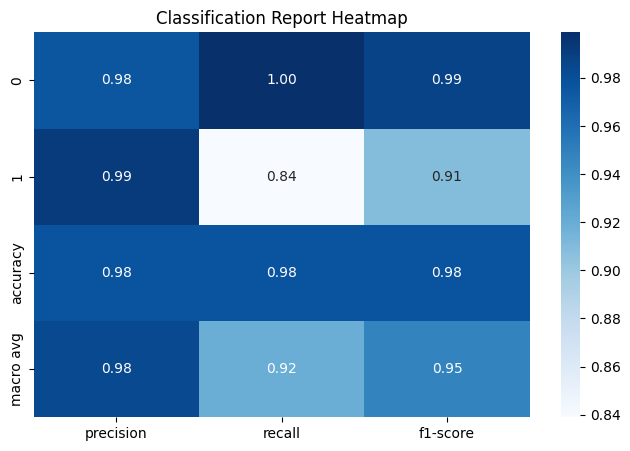

In [127]:
report = classification_report(y_test, y_pred, output_dict=True)

df_report = pd.DataFrame(report).transpose()  # convert report into dataframe so we can use it for visualiztion

plt.figure(figsize=(8, 5))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="Blues", fmt=".2f")

plt.title("Classification Report Heatmap")
plt.show()

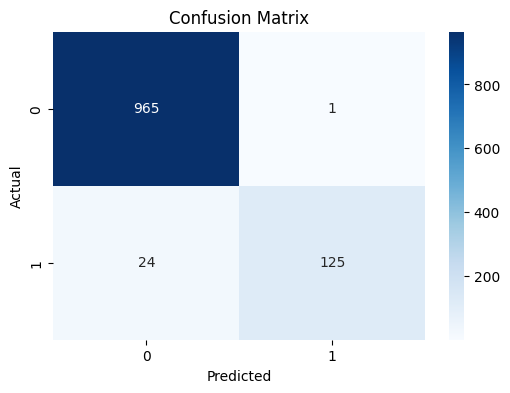

In [128]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Plot confusion matrix as heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()